In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv(
    "../Bluestock-Capstone/data/processed/02_nav_history_clean.csv"
)

transactions = pd.read_csv(
    "../Bluestock-Capstone/data/processed/08_investor_transactions_clean.csv"
)

holdings = pd.read_csv(
    "../Bluestock-Capstone/data/processed/09_portfolio_holdings.csv"
)

performance = pd.read_csv(
    "../Bluestock-Capstone/data/processed/07_scheme_performance_clean.csv"
)

fund_master = pd.read_csv(
    "../Bluestock-Capstone/data/processed/01_fund_master.csv"
)

In [3]:
print("NAV")
print(nav.columns.tolist())

print("\nTRANSACTIONS")
print(transactions.columns.tolist())

print("\nHOLDINGS")
print(holdings.columns.tolist())

print("\nPERFORMANCE")
print(performance.columns.tolist())

print("\nFUND MASTER")
print(fund_master.columns.tolist())

NAV
['amfi_code', 'date', 'nav']

TRANSACTIONS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

HOLDINGS
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

PERFORMANCE
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

FUND MASTER
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
results = []

for fund, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) < 30:
        continue

    var95 = returns.quantile(0.05)

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append({
        "amfi_code": fund,
        "VaR_95": round(var95, 6),
        "CVaR_95": round(cvar95, 6)
    })

var_cvar = pd.DataFrame(results)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("saved")

saved


In [7]:
var_cvar.sort_values(
    "VaR_95"
).head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [8]:
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [9]:
top5 = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)
)

top5[[
    "amfi_code",
    "scheme_name",
    "sharpe_ratio"
]]

,amfi_code,scheme_name,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


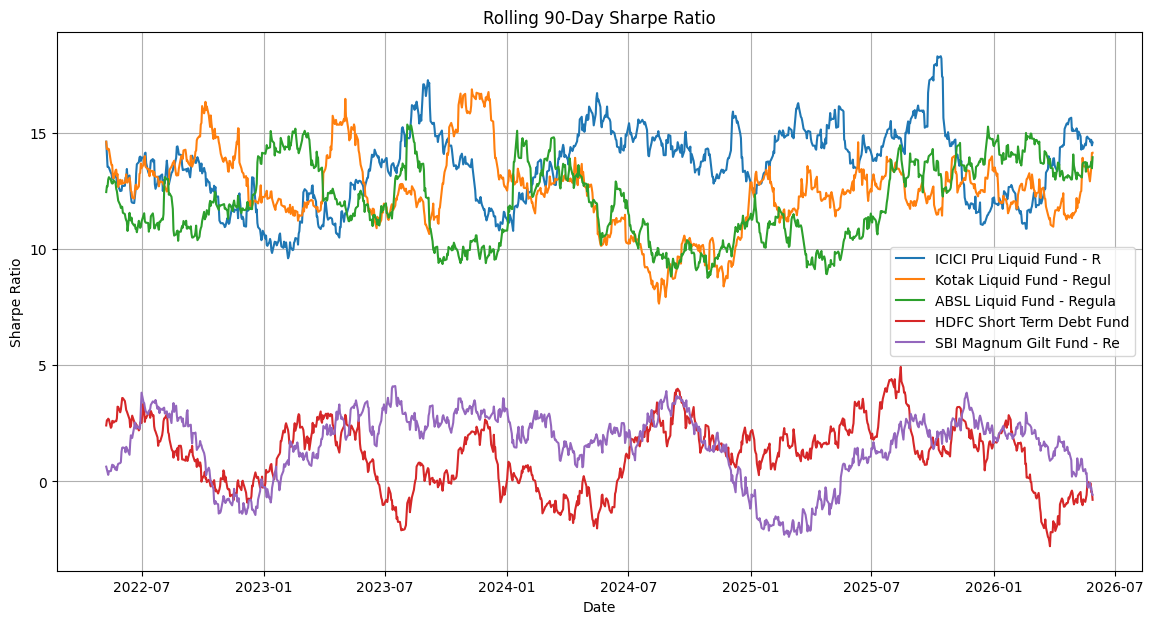

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for fund in top5["amfi_code"]:

    temp = (
        nav[nav["amfi_code"] == fund]
        .sort_values("date")
        .copy()
    )

    sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    name = (
        performance.loc[
            performance["amfi_code"] == fund,
            "scheme_name"
        ].iloc[0]
    )

    plt.plot(
        temp["date"],
        sharpe,
        label=name[:25]
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [11]:
transactions.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [12]:
transactions.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [13]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

transactions = transactions.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id"
)

In [14]:
cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum"),
        investor_count=("investor_id","nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [15]:
top_funds = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="txn_count")
)

top_funds = (
    top_funds
    .sort_values(
        ["cohort_year","txn_count"],
        ascending=[True,False]
    )
    .drop_duplicates("cohort_year")
)

top_funds.head()

,cohort_year,amfi_code,txn_count
35,2024,148568,874
62,2025,119599,12


In [16]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

In [17]:
sip_txns = transactions[
    transactions["transaction_type"]
    .str.upper()
    == "SIP"
].copy()

In [18]:
eligible = (
    sip_txns
    .groupby("investor_id")
    .size()
)

eligible = eligible[
    eligible >= 6
].index

In [19]:
results = []

for investor in eligible:

    temp = (
        sip_txns[
            sip_txns["investor_id"]
            == investor
        ]
        .sort_values(
            "transaction_date"
        )
    )

    gaps = (
        temp["transaction_date"]
        .diff()
        .dt.days
    )

    avg_gap = gaps.mean()

    status = (
        "At-Risk"
        if avg_gap > 35
        else "Healthy"
    )

    results.append({
        "investor_id": investor,
        "avg_gap_days": round(avg_gap,2),
        "status": status
    })

sip_continuity = pd.DataFrame(results)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.40,At-Risk
1,INV000008,70.40,At-Risk
2,INV000010,64.80,At-Risk
3,INV000011,40.17,At-Risk
4,INV000012,57.00,At-Risk


In [20]:
sip_continuity.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

In [21]:
holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [22]:
sector_weights = (
    holdings
    .groupby(
        ["amfi_code", "sector"]
    )["weight_pct"]
    .sum()
    .reset_index()
)

sector_weights.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [23]:
hhi = (
    sector_weights
    .groupby("amfi_code")["weight_pct"]
    .apply(
        lambda x: ((x/100) ** 2).sum()
    )
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [24]:
def classify_hhi(hhi_score):

    if hhi_score < 0.15:
        return "Diversified"

    elif hhi_score < 0.25:
        return "Moderately Concentrated"

    else:
        return "Highly Concentrated"


hhi["concentration"] = (
    hhi["HHI"]
    .apply(classify_hhi)
)

hhi.head()

,amfi_code,HHI,concentration
0,100016,0.180588,Moderately Concentrated
1,100033,0.227647,Moderately Concentrated
2,101206,0.180042,Moderately Concentrated
3,101207,0.222727,Moderately Concentrated
4,102885,0.180712,Moderately Concentrated


In [25]:
hhi = hhi.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,concentration,scheme_name
0,100016,0.180588,Moderately Concentrated,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.227647,Moderately Concentrated,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.180042,Moderately Concentrated,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.222727,Moderately Concentrated,ABSL Small Cap Fund - Regular - Growth
4,102885,0.180712,Moderately Concentrated,UTI Nifty 50 Index Fund - Regular - Growth


In [26]:
hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

print("sector_hhi.csv saved")

sector_hhi.csv saved


In [27]:
print("Advanced Analytics Completed Successfully")
print("Deliverables Generated:")
print("- var_cvar_report.csv")
print("- rolling_sharpe_chart.png")
print("- cohort_analysis.csv")
print("- sip_continuity.csv")
print("- sector_hhi.csv")

Advanced Analytics Completed Successfully
Deliverables Generated:
- var_cvar_report.csv
- rolling_sharpe_chart.png
- cohort_analysis.csv
- sip_continuity.csv
- sector_hhi.csv


# Business Recommendations

1. Investors with low risk appetite should prioritize funds with strong Sharpe ratios and low CVaR values.

2. Fund houses should monitor investors classified as At-Risk and proactively engage them before SIP discontinuation.

3. Highly concentrated funds should be evaluated alongside diversified alternatives to balance return potential and risk exposure.

4. Cohort-level behavioural analysis can help identify the most valuable investor segments for future acquisition campaigns.

5. Risk-adjusted performance metrics should be considered alongside absolute returns when evaluating mutual fund quality.